In [ ]:
import pandas as pd
import sklearn
from google.colab import files
import gdown
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from tqdm.auto import tqdm
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import hdbscan
import hdbscan.validity as hdbscan_validity
import seaborn as sns
import math
import os
from scipy.signal import find_peaks
import gc

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams['figure.dpi'] = 80
plt.rcParams['savefig.dpi'] = 80

DATA_ID = "1SFKR_2cZ-3xRfAZ4ZfCffkIj-i3MonMU"
DATA_NAME = "Run200_Wave_0_1.txt"

# Загрузка и изучение датасета

In [ ]:
gdown.download(id=DATA_ID, output=DATA_NAME)
data = pd.read_csv(DATA_NAME, sep=' ', header=None, skipinitialspace=True)
data.head()

In [ ]:
# вспомогательные и Nan-колонки
data.drop(columns=[0, 1, 2, 3, 504], inplace=True)
data.columns = list(range(500))

In [ ]:
data.info()

In [ ]:
print(f"размер: {data.shape}")
print(f"пропуски: {data.isna().sum().sum()}")
print(f"дубликаты: {data.duplicated().sum()}")

После очистки вспомогательных и Nan-колонок в датасете осталось 23479 сигналов, 500 отсчетов, 0 пропусков, 0 дублирующих записей.

# EDA

Подготовка формы сигнала

In [ ]:
X_signal = (2**14 - data.astype('float32') - 1560).to_numpy(dtype=np.float32)

time_range = np.arange(140, 201)
mean_signal = X_signal.mean(axis=0)
std_signal = X_signal.std(axis=0)

mean_strip = mean_signal[time_range]
std_strip = std_signal[time_range]

plt.figure(figsize=(10, 5))
for i in range(25):
    plt.plot(time_range, X_signal[i, time_range], alpha=0.6)


plt.plot(time_range, mean_strip, color='red', alpha=0.9, linewidth=2, label='Средний сигнал')
plt.fill_between(time_range, mean_strip - std_strip, mean_strip + std_strip,
                 color='red', alpha=0.2, label='±1 Std Dev')

plt.title('25 преобразованных сигналов')
plt.xlabel('Отсчет')
plt.ylabel('Амплитуда')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
q05 = np.quantile(X_signal, 0.05, axis=0)
q95 = np.quantile(X_signal, 0.95, axis=0)
range_ = X_signal.max(axis=0) - X_signal.min(axis=0)

time = np.arange(mean_signal.shape[0])

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(time, std_signal)
axes[0].set_title("Стандартное отклонение")

axes[1].plot(time, range_)
axes[1].set_title("Размах (max - min)")

for ax in axes:
    ax.grid(alpha=0.3)
    ax.set_xlabel('Отсчет')

plt.tight_layout()
plt.show()

Основной импульс в окне 145-160 отсчетов, остальное - зона покоя.

Сравнение среднего и перцентилей указывает на большой разброс амплитуд.
95й перцентиль существенно выше среднего, что говорит об асимметричности распределения: большинство импульсов имеют умеренную амплитуду, но есть хвост высокоэнергетических сигналов.

Пик стандартного отклонения совпадает по времени с импульсом, то есть главное различие между сигналами в амплитуде, а не в форме или фоне.

На графике размаха вершина плоская - вероятно, датчик ограничил диапазон самых сильных сигналов

Также на графике размаха заметен дополнительный менее выраженный всплеск в районе 470-480 отсчётов. Это может быть связано с наличием у небольшой доли сигналов второго импульса или сдвигом основного пика  - проверю это дальше.


In [ ]:
# распределения baseline и амплитуды
baseline_per_signal = X_signal[:, :140].mean(axis=1)
peak_val = X_signal.max(axis=1)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(baseline_per_signal, bins=60, ax=ax[0])
ax[0].set_title("Распределение baseline по записям")

sns.histplot(peak_val, bins=50, ax=ax[1])
ax[1].set_title("Распределение амплитуды")

for a in ax:
  a.grid(alpha=0.3)

plt.tight_layout()
plt.show()

`baseline` распределён близко к нормальному, без второй моды или обособленной группы выбросов — как самостоятельный признак для выделения аномальных записей выглядит слабым кандидатом.

Амплитуда пика распределена с сильной правой асимметрией: основная масса сигналов имеет умеренную амплитуду, но присутствует длинный хвост редких высокоамплитудных сигналов.

In [ ]:
# распределение пиков
peak_idx = X_signal.argmax(axis=1)
peak_threshold = peak_idx.mean() + 3 * peak_idx.std()

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(peak_idx, bins=50, ax=ax[0])
ax[0].set_title("Распределение индекса пика")
ax[0].set_xlabel("Отсчет")

sns.histplot(peak_idx, bins=80, log_scale=(False, True), ax=ax[1], edgecolor='black', linewidth=2, alpha=1)
ax[1].set_title("Индекс пика")
ax[1].axvline(peak_threshold, color="red", linestyle="--", label=f"mean+3std = {peak_threshold:.2f}")
ax[1].set_title("Пик по записям")
ax[1].set_xlabel("Отсчет")
ax[1].legend()

for a in ax:
  a.grid(alpha=0.3)


plt.tight_layout()
plt.show()

Большинство пиков импульсов приходится на узкое окно 149–155 отсчетов, граница mean+3std проходит на отметке 157,1.

Логарифмический график показывает единичный выброс в около 470 отсчета.

In [ ]:
# Распределение СКО шумового окна по записям
noise_std_per_signal = X_signal[:, :140].std(axis=1)

noise_threshold = noise_std_per_signal.mean() + 3 * noise_std_per_signal.std()
outlier_mask = noise_std_per_signal > noise_threshold
n_outliers = (outlier_mask).sum()
print(f"Порог (mean+3std): {noise_threshold:.2f}")
print(f"Сигналов с noise_std выше порога: {n_outliers} ({n_outliers / len(noise_std_per_signal):.3%})")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(noise_std_per_signal, bins=60, ax=ax[0])
ax[0].set_title("Распределение Noise std по записям")
ax[0].set_xlabel("noise_std")
ax[0].grid(alpha=0.3)

sns.histplot(noise_std_per_signal, bins=80, log_scale=(False, True), ax=ax[1], edgecolor='black', linewidth=2, alpha=1)
ax[1].axvline(noise_threshold, color="red", linestyle="--", label=f"mean+3std = {noise_threshold:.2f}")
ax[1].set_title("Распределение Noise std по записям")
ax[1].set_xlabel("noise_std")
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


На логарифмическом масштабе видны аномально "грязные" сигналы с noise std больше порога (mean+3std = 3.2). Эти сигналы могут быть связаны с 3 группой неклассифицируемых сигналов.

В дальнейшем feature engineering нужно будет вычесть из каждого сигнала baseline, посчитанный на шумовом окне, для получения более корректных результатов.

In [ ]:
# сигналы с большим СКО шумового окна
noise_outlier_indices = np.where(outlier_mask)[0]
noise_outlier_indices

In [ ]:
# наиболее разнообразные и показательные сигналы
noise_outlier_set = [85, 2078, 3039, 3321, 5537, 20720]

fig, axes = plt.subplots(3, 2, figsize=(12, 6), sharex=True, dpi=80)
axes = axes.flatten()

for ax, idx in zip(axes, noise_outlier_set):
    ax.plot(X_signal[idx], linewidth=1)
    ax.set_title(
        f"Сигнал #{idx} | noise_std = {noise_std_per_signal[idx]:.2f}",
        fontsize=9,
    )
    ax.set_ylabel("Амплитуда", fontsize=8)
    ax.grid(alpha=0.3)

for ax in axes[len(noise_outlier_set) :]:
    ax.axis("off")

plt.tight_layout()
plt.show()

Повышенный noise_std у большинства сигналов этой группы вызван пред-импульсами или более высоким общим уровнем шума (мелкими колебаниями) по всей длине записи. Из-за этого флуктуации зоны покоя естественным образом превышают порог. В редких случаях превышение вызвано попаданием. Отдельные сигналы содержат паразитные колебания («звон») на спадающем фронте.


In [ ]:
def count_local_peaks(row, prominence_frac=0.5):
    prominence = prominence_frac * (row.max() - row.min())
    peaks, _ = find_peaks(row, prominence=prominence)
    return len(peaks)


n_peaks = np.apply_along_axis(count_local_peaks, 1, X_signal[:, 130:])
multi_peak_idx = np.where(n_peaks > 1)[0]
multi_peak_frac = (n_peaks > 1).mean()
print(f"Доля сигналов с >1 выраженным локальным максимумом: {multi_peak_frac:.2%} "
      f"({len(multi_peak_idx)} из {len(n_peaks)})")

peak_outlier_set = [1929, 9703, 10226, 13622, 20630, 22434]

fig, axes = plt.subplots(2, 3, figsize=(12, 5), sharex=True, dpi=80)
axes = axes.flatten()

for ax, idx in zip(axes, peak_outlier_set):
    ax.plot(time, X_signal[idx, :], linewidth=1)
    ax.set_title(f"Сигнал #{idx}", fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("Примеры сигналов с >1 выраженным локальным максимумом (выборка)")
plt.tight_layout()
plt.show()

Выявлено всего 19 сигналов (~0.08% от всей выборки) с несколькими локальными максимумами, они являются редкими аномалиями в датасете. Визуально можно выделить два сценария: повторное срабатывание детектора с разнесением во времени (сигнал №1929 со второй полноценной вспышкой на 470-м отсчете) и наложение близких импульсов с изломами на падающем фронте (например, №9703, №10226, №13622, №20630). Оба случая делают невозможным разделение частиц по форме отклика — такие события представляют собой 3-ю группу неклассифицируемых сигналов.

# Feature Engineering

In [ ]:
# Вспомогательные функции
def first_consecutive_true(mask, consecutive=3):
    """Находит первый индекс, где подряд идут consecutive значений True"""
    mask = np.asarray(mask, dtype=bool)
    run = 0
    for i, v in enumerate(mask):
        run = run + 1 if v else 0
        if run >= consecutive:
            return i - consecutive + 1
    return None


def find_signal_end(y, peak_idx, noise_std, end_sigma=3.0, consecutive=3):
    """Находит конец импульса после пика"""
    thr = end_sigma * max(float(noise_std), 1e-6)
    tail = y[peak_idx:]
    below = tail <= thr
    local = first_consecutive_true(below, consecutive=consecutive)
    if local is None:
        return len(y) - 1
    return min(peak_idx + local, len(y) - 1)


In [ ]:
# Извлечение признаков
def extract_features(X_signal, noise_window=140, short_gate=18):
    """
    Возвращает features   - DataFrame с физическими признаками
    """
    rows = []

    for x in X_signal:
        baseline = float(np.mean(x[:noise_window]))
        noise_std = float(np.std(x[:noise_window]) + 1e-6)

        y = x - baseline
        peak_idx = int(np.argmax(y))
        peak_amp = float(max(y[peak_idx], 0.0))

        signal_end_idx = find_signal_end(
            y=y,
            peak_idx=peak_idx,
            noise_std=noise_std,
            end_sigma=3.0,
            consecutive=3,
        )

        seg = np.clip(y[peak_idx:signal_end_idx + 1], 0.0, None)

        signal_length = int(len(seg))
        area_total = float(np.sum(seg) + 1e-6)

        head_len = min(short_gate, signal_length)
        area_head = float(np.sum(seg[:head_len]) + 1e-6)
        area_tail = float(area_total - area_head)

        psd = float(area_tail / area_total)
        decay_len = max(signal_end_idx - peak_idx, 1)

        energy = float(np.sum(seg ** 2))
        if signal_length > 0:
            mean_seg = float(np.mean(seg))
            std_seg = float(np.std(seg))
            com = float(np.sum(np.arange(signal_length) * seg) / (np.sum(seg) + 1e-6))
        else:
            mean_seg = np.nan
            std_seg = np.nan
            com = np.nan
            width = np.nan

        rows.append({
            "baseline": baseline,
            "noise_std": noise_std,
            "peak_idx": peak_idx,
            "peak_amp": peak_amp,
            "peak_snr": float(peak_amp / noise_std),
            "signal_end_idx": signal_end_idx,
            "signal_length": signal_length,
            "area_total": area_total,
            "area_head": area_head,
            "area_tail": area_tail,
            "psd": psd,
            "rise_slope": float(peak_amp / peak_idx),
            "fall_slope": float(peak_amp / decay_len),
            "energy": energy,
            "mean_seg": mean_seg,
            "std_seg": std_seg,
            "center_of_mass": com,
        })

    features = pd.DataFrame(rows)
    return features



In [ ]:
features = extract_features(X_signal)

In [ ]:
print("размер:", features.shape)
print("пропуски:", features.isna().sum().sum())
print("дубликаты:", features.duplicated().sum())
display(features.describe().T)

In [ ]:
# распределения новых признаков
fig, axes = plt.subplots(5, 4, figsize=(20, 16))

axes_flat = axes.flatten()

for i, col_name in enumerate(features.columns):
    ax = axes_flat[i]
    sns.histplot(data=features, x=col_name, kde=True, ax=ax)
    ax.set_title(col_name)
    ax.set_xlabel('')
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()



In [ ]:
# коррляция признаков
plt.figure(figsize=(12, 10))
sns.heatmap(features.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Корреляция признаков")
plt.tight_layout()
plt.show()

In [ ]:
# Парные графики распределения
# Отобраны признаки, показывающие визуально хорошее разделение
features_for_pairplot = ["peak_amp", "peak_snr", "psd", "fall_slope", "center_of_mass"]

sns.pairplot(features[features_for_pairplot], diag_kind='kde', corner=True,
             height=1.5, aspect=1.0, plot_kws={'alpha':0.2, 's':6, 'rasterized': True})
plt.suptitle('Pairplot извлеченных признаков', y=1.02)
plt.show()

In [ ]:
ext_for_pca = ["peak_snr", "area_total", "energy", "mean_seg", "std_seg", "center_of_mass"]
may_be_unclassified = ["baseline", "noise_std", "peak_idx"]
base_feats = ["psd", "fall_slope", "fwhm", "signal_length", "area_tail", "peak_amp"]

# log_transform = ["peak_amp", "area_total", "area_tail", "energy", "std_seg", "mean_seg"]
# log_transform = ["peak_amp", "peak_snr", "signal_length", "area_total"]
# log_transform = ["peak_amp"]

# roots = ["peak_amp", "peak_snr", "signal_length", "area_total", "psd"]
roots = ["fwhm", "peak_amp", "peak_snr", "signal_length", "area_total", "psd"]
psd_peakA_set = ["psd", "peak_amp"]
psd_fallslope_set = ["psd", "fall_slope"]
roots_uncl =  list(dict.fromkeys(roots + ext_for_pca + may_be_unclassified))

# data_set = psd_peakA_set

rise_slope и peak_amp имеют корреляцию = 1, так как rise_slope = peak_amp / peak_idx, который слабо изменяется. Поэтому rise_slope удаляем

Корреляции area_head: с peak_amp = 0.99, с area_total = 1, удаляем

signal_end_idx коррелирует с signal_length с силой 1. Удаляем

Эмперически выявлено, что log ухудшает результат, вероятно, в хвостах находится полезный сигнал

In [ ]:
outlier_idx = np.where(outlier_mask)[0]
print(features.loc[outlier_idx, ["noise_std", "peak_amp", "peak_snr", "psd", "fall_slope"]].describe())
print("/n")
print(features.loc[~outlier_mask, ["noise_std", "peak_amp", "peak_snr", "psd", "fall_slope"]].describe())

Сравнение psd/fall_slope между записями с аномально высоким noise_std и остальными не выявило значимых различий (разница средних меньше одного стандартного отклонения, полное перекрытие распределений) — то есть шумность измерения baseline не связана с физическим типом сигнала. Это подтверждает решение не включать noise_std в набор признаков для кластеризации: он измеряет качество/условия измерения, а не физику импульса, и его добавление к рабочим psd+fall_slope/peak_amp только размывает геометрию, эмпирически подтверждено падением качества кластеризации при попытке включения.

# Предподготовка

In [ ]:
X_peak = features[psd_peakA_set].copy()
X_fallslope = features[psd_fallslope_set].copy()

In [ ]:
scaler = StandardScaler()

X_scaled_peakA = scaler.fit_transform(X_peak)
X_scaled_fallslope = scaler.fit_transform(X_fallslope)

Снижение размерности

In [ ]:
def print_pca_loadings(pca, feature_names, top_n=5):
    """
    Выводит признаки с наибольшими абсолютными loadings
    для каждой главной компоненты PCA.
    """
    loadings = pca.components_.T

    # Топ-N признаков для каждой компоненты
    for i in range(pca.n_components_):
        pc_name = f"PC{i + 1}"

        top_indices = (np.argsort(np.abs(loadings[:, i]))[::-1][:top_n])

        print(f"\n{pc_name}:")

        for idx in top_indices:
            feat = feature_names[idx]
            value = loadings[idx, i]

            print(f"  {feat}: {abs(value):.3f} (знак {np.sign(value):+.0f})")

In [ ]:
pca095 = PCA(n_components=0.95, random_state=RANDOM_STATE)

X_reduced_095_peakA = pca095.fit_transform(X_scaled_peakA)

print(f"Форма peakA с 0.95: {X_reduced_095_peakA.shape}")
print(f"Объясненная дисперсия 095: {pca095.explained_variance_ratio_.sum():.3f}")
print_pca_loadings(pca095, psd_peakA_set)

print("________________________________\n")
X_reduced_095_fallslope = pca095.fit_transform(X_scaled_fallslope)
print(f"Форма fallslope с 0.95: {X_reduced_095_fallslope.shape}")
print(f"Объясненная дисперсия 095: {pca095.explained_variance_ratio_.sum():.3f}")
print_pca_loadings(pca095, psd_fallslope_set)

Для итоговых наборов признаков (psd_peakA_set, psd_fallslope_set) выполнен PCA(0.95), который в данном случае по сути является поворотом системы координат. Это решение обосновано двумя наблюдениями. Во-первых, евклидова метрика устойчива к повороту, поэтому raw и PCA(0.95) дают идентичные результаты. Однако сравнение на манхэттенской метрике не устойчивой к повороту показало, что PCA-версия дает результат не хуже, а часто лучше, чем raw-версия. Порог 0.95 (а не 0.99) выбран, поскольку проверка explained_variance_ratio_ показала, что уже при этом пороге сохраняются обе компоненты для обоих наборов признаков — дальнейшее повышение порога не меняет число сохранённых компонент и, следовательно, не может изменить результат кластеризации.

In [ ]:
feature_sets = {
    "psd_peakA_set": {
        "data_dict": {"X": X_scaled_peakA, "X_reduced_095": X_reduced_095_peakA},
        # "mcs_grid": [400, 450, 550, 650, 750, 4100],
        #  "mcs_grid": [1060, 4100, 4150],
        # "mcs_grid": [1061, 4100, 4160, 4186, 4196],
        "mcs_ms_pairs": [(4186, 60), (4160, 80), (4196, 50), (1061, 150)]
    },
    "psd_fallslope_set": {
        "data_dict": {"X": X_scaled_fallslope, "X_reduced_095": X_reduced_095_fallslope},
        # "mcs_grid": [750, 850, 4100, 4200, 4500],
        # "mcs_grid": [4150, 4250, 4500],
        # "mcs_grid": [850, 4100, 4173, 4196, 4200, 4250, 4500, 4534],
        "mcs_ms_pairs": [(4534, 125), (4173, 200), (4250, 80), (4534, 218), (4200, 63), (850, 212), (4250, 204), (4100, 718)]
    },
    # "roots_uncl": {
    #     "data_dict": {"X_reduced_095": X_reduced_095_roots_unc, "X_reduced_099": X_reduced_099_roots_unc},
    #    "mcs_grid": [200, 300, 400, 500, 1000],
    #     "ms_fracs": [0.001, 0.01, 0.15, 0.25]
    # },
}

Проведены тесты с несколькими наборами признаков, лучше всего себя показали наборы: "psd"+"peak_amp", "psd"+"fall slope"

К данным применен StandardScaler. RobustScaler и log ухудшили результаты. PCA(0.95) объясняет

## Подбор гиперпараметров

In [ ]:
_SKLEARN_TO_SCIPY_METRIC = {
    "manhattan": "cityblock",
    "l1": "cityblock",
    "l2": "euclidean",
}

def to_scipy_metric_name(metric):
    return _SKLEARN_TO_SCIPY_METRIC.get(metric, metric)

def stratified_subsample(X, labels, max_per_cluster=2000, random_state=None):
    rng = np.random.default_rng(random_state)
    idx_parts = []
    for lab in np.unique(labels):
        idx = np.where(labels == lab)[0]
        if len(idx) > max_per_cluster:
            idx = rng.choice(idx, size=max_per_cluster, replace=False)
        idx_parts.append(idx)
    idx_all = np.concatenate(idx_parts)
    return X[idx_all], labels[idx_all]

def safe_silhouette(X_eff, labels_eff, metric, sample_size, random_state=0):
    n_labels = len(np.unique(labels_eff))
    if sample_size is not None and sample_size < len(labels_eff):
        X_s, labels_s = stratified_subsample(
            X_eff, labels_eff,
            max_per_cluster=max(2, sample_size // n_labels),
            random_state=random_state,
        )
    else:
        X_s, labels_s = X_eff, labels_eff

    if len(np.unique(labels_s)) < 2:
        return np.nan
    return silhouette_score(X_s, labels_s, metric=metric)

def dbcv_bootstrap(X_eff, labels_eff, metric, n_runs=3, max_per_cluster=2000, min_cl_size_for_dbcv=5):
    counts = pd.Series(labels_eff).value_counts()
    if counts.min() < min_cl_size_for_dbcv:
        return np.nan, np.nan

    scipy_metric = to_scipy_metric_name(metric)
    scores = []
    for i in range(n_runs):
        X_sub, labels_sub = stratified_subsample(
            X_eff, labels_eff, max_per_cluster=max_per_cluster, random_state=i
        )
        try:
            score = hdbscan_validity.validity_index(
                np.asarray(X_sub, dtype=np.float64), labels_sub.astype(np.intp), metric=scipy_metric
            )
            scores.append(float(score))
        except Exception as e:
            print("dbcv error:", repr(e))
            continue
    if not scores:
        return np.nan, np.nan
    return float(np.mean(scores)), float(np.std(scores))

def evaluate_clustering(X, labels, metric="euclidean", noise_label=None,
                         silhouette_sample_size=5000, dbcv_max_per_cluster=2000, dbcv_runs=3):
    labels = np.asarray(labels)

    if noise_label is None:
        mask = np.ones(len(labels), dtype=bool)
    else:
        mask = labels != noise_label

    X_eff = np.asarray(X)[mask]
    labels_eff = labels[mask]
    unique_labels = np.unique(labels_eff)

    out = {
        "n_points": len(labels),
        "n_used": int(mask.sum()),
        "noise_frac": float(1 - mask.mean()) if noise_label is not None else 0.0,
        "n_clusters": int(len(unique_labels)),
    }

    if len(unique_labels) < 2 or len(labels_eff) < 3:
        out.update({
            "silhouette": np.nan, "davies_bouldin": np.nan, "calinski_harabasz": np.nan,
            "dbcv": np.nan, "dbcv_std": np.nan, "min_cluster_size": np.nan, "size_ratio": np.nan,
        })
        return out

    sizes = pd.Series(labels_eff).value_counts()
    out.update({
        "silhouette": safe_silhouette(
            X_eff, labels_eff, metric=metric,
            sample_size=silhouette_sample_size, random_state=RANDOM_STATE
        ),
        "davies_bouldin": davies_bouldin_score(X_eff, labels_eff),
        "calinski_harabasz": calinski_harabasz_score(X_eff, labels_eff),
        "min_cluster_size": int(sizes.min()),
        "size_ratio": float(sizes.max() / sizes.min()),
    })

    try:
        dbcv_mean, dbcv_std = dbcv_bootstrap(
            X_eff, labels_eff, metric=metric,
            n_runs=dbcv_runs, max_per_cluster=dbcv_max_per_cluster
        )
        out["dbcv"] = dbcv_mean
        out["dbcv_std"] = dbcv_std
    except Exception as e:
        out["dbcv"] = np.nan
        out["dbcv_std"] = np.nan
        print("dbcv error:", repr(e))
    return out

In [ ]:
def flatten_feature_sets(feature_sets):
    data_dict = {}

    for feature_set_name, config in feature_sets.items():
        for representation_name, X in config["data_dict"].items():
            name = f"{feature_set_name}__{representation_name}"
            data_dict[name] = X

    return data_dict

data_dict = flatten_feature_sets(feature_sets)

## Agglomerative

In [ ]:
LINKAGE_TO_METRICS = {
    "ward": ["euclidean"],
    "complete": ["euclidean", "manhattan", "cosine"],
    "average": ["euclidean", "manhattan", "cosine"],
}

def build_agglomerative_grid(data_dict, linkage_map=LINKAGE_TO_METRICS):
    grid = []
    for name, X in data_dict.items():
        for linkage, allowed_metrics in linkage_map.items():
            for metric in allowed_metrics:
                grid.append((name, X, linkage, metric))
    return grid

def run_one(name, X, linkage, metric):
    X = np.asarray(X, dtype=np.float32
    )
    row = {"model": "Agg", "X": name, "linkage": linkage, "metric": metric}
    try:
        model = AgglomerativeClustering(
            n_clusters=3,
            linkage=linkage,
            metric=metric,
        )
        labels = model.fit_predict(X)
        eval_metrics = evaluate_clustering(X, labels, metric=metric, dbcv_max_per_cluster=4000)
        row.update(eval_metrics)
        del model, labels
    except Exception as e:
        print(f"run_one error [{name}, {linkage}, {metric}]:", repr(e))
        row.update({
            "n_points": len(X), "n_used": np.nan, "noise_frac": np.nan, "n_clusters": np.nan,
            "silhouette": np.nan, "davies_bouldin": np.nan, "calinski_harabasz": np.nan,
            "dbcv": np.nan, "dbcv_std": np.nan, "min_cluster_size": np.nan, "size_ratio": np.nan,
        })
    del X
    gc.collect()
    return row

def search_agglomerative(data_dict, out_path="agg_search_checkpoint.csv"):
    grid = build_agglomerative_grid(data_dict)

    done = set()
    header_written = False
    if os.path.exists(out_path):
        Existing = pd.read_csv(out_path)
        done = set(zip(Existing["X"], Existing["linkage"], Existing["metric"]))
        header_written = True

    for name, X, linkage, metric in tqdm(grid, total=len(grid), desc="Agglomerative search"):
        if (name, linkage, metric) in done:
            continue
        row = run_one(name, X, linkage, metric)
        pd.DataFrame([row]).to_csv(
            out_path, mode="a", header=not header_written, index=False
        )
        header_written = True
        del row
        gc.collect()

    return pd.read_csv(out_path)

another_agg_res = search_agglomerative(data_dict)

another_agg_res.sort_values(["dbcv", "silhouette"], ascending=[False, False])

In [ ]:
filtered_agg_res = another_agg_res[
    ~(another_agg_res["metric"].isin(["euclidean", "cosine"]) & (another_agg_res["X"].isin(["psd_peakA_set__X_reduced_095", "psd_fallslope_set__X_reduced_095"])))
].sort_values(["dbcv", "silhouette"], ascending=[False, False])
filtered_agg_res

6, 13 модели отсеяны, так как dbcv_std большой, а значит разбиение нестабильно

18, 15, 23 небольшой минимальный кластер

все модели cosine-euclidean pca095 исключены, так как дают приблизительно тот же результат, что и raw-версии из-за инвариантности алгоритма к повороту.

Все значения DBCV отрицательные. Значит, что ни одно разбиение не выглядит как хорошие плотностные кластеры - вероятно, структура данных недостаточно хорошо описывается даже этой метрикой на 2 признаках. Поэтому DBCV использую только для относительного ранжирования, а не абсолютный вердикт

In [ ]:
def plot_agg_results(filtered_res, data_dict, feature_name, cols=4):
    n_plots = len(filtered_res)
    rows = math.ceil(n_plots / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows), dpi=60)

    axes = np.atleast_1d(axes).flatten()

    for i, ax in enumerate(axes):
        if i >= n_plots:
            ax.axis("off")
            continue

        row = filtered_res.iloc[i]
        x_name = row["X"]
        X_curr = data_dict[x_name]

        model = AgglomerativeClustering(
            n_clusters=3,
            linkage=row["linkage"],
            metric=row["metric"]
        )

        labels = model.fit_predict(X_curr)

        sns.scatterplot(x=X_curr[:, 0], y=X_curr[:, 1], hue=labels, palette="Set1",
            s=10, alpha=0.7, ax=ax, legend=False)

        prep = "pca95" if "reduced_095" in x_name else "raw"

        ax.set_title(f"{prep} | {row['linkage']} + {row['metric']}", fontsize=9, pad=5)

        ax.set_xticks([])
        ax.set_yticks([])

        if prep == "PCA95":
            ax.set_xlabel("PC1", fontsize=8)
            ax.set_ylabel("PC2", fontsize=8)
        else:
            ax.set_xlabel("Feature 1", fontsize=8)
            ax.set_ylabel("Feature 2", fontsize=8)

    fig.suptitle(
        f"Agglomerative — {feature_name}", fontsize=12, y=1.02)

    plt.tight_layout()
    plt.show()


# PSD + peak_amp
psd_peakA_res = filtered_agg_res[filtered_agg_res["X"].isin([
    "psd_peakA_set__X", "psd_peakA_set__X_reduced_095"])]

plot_agg_results(psd_peakA_res, data_dict, feature_name="PSD + Peak Amplitude")

In [ ]:
# PSD + fall_slope
psd_fallslope_res = filtered_agg_res[
    filtered_agg_res["X"].isin([
        "psd_fallslope_set__X",
        "psd_fallslope_set__X_reduced_095"
    ])
]

plot_agg_results(
    psd_fallslope_res,
    data_dict,
    feature_name="PSD + Fall Slope"
)

Остальные модели выбраны визуально по графикам. Предпочтение отдано разделениям: две ветки - два кластера частиц, третий - "кончики" - неклассифицируемые сигналы. Выбросы от нормальных сигналов.

In [ ]:
best_models_agg = {
    "Agg_fallslope_pca095_average_man": {
        "X": feature_sets['psd_fallslope_set']["data_dict"]["X_reduced_095"],
        "model": AgglomerativeClustering(
            n_clusters=3,
            linkage="average",
            metric="manhattan",
        )
    },
    "Agg_fallslope_raw_average_man": {
        "X": feature_sets['psd_fallslope_set']["data_dict"]["X"],
        "model": AgglomerativeClustering(
            n_clusters=3,
            linkage="average",
            metric="manhattan",
        )
    },
    "Agg_peakA_pca095_average_man": {
        "X": feature_sets['psd_peakA_set']["data_dict"]["X_reduced_095"],
        "model": AgglomerativeClustering(
            n_clusters=3,
            linkage="average",
            metric="manhattan",
        )
    },
    "Agg_fallslope_raw_complete_cos": {
        "X": feature_sets['psd_fallslope_set']["data_dict"]["X"],
        "model": AgglomerativeClustering(
            n_clusters=3,
            linkage="complete",
            metric="cosine",
        )
    },
    "Agg_peakA_raw_complete_cos": {
        "X": feature_sets['psd_peakA_set']["data_dict"]["X"],
        "model": AgglomerativeClustering(
            n_clusters=3,
            linkage="complete",
            metric="cosine",
        )
    },
}



## GMM


In [ ]:
def search_gmm(data_dict, covariance_types=("full", "diag", "tied")):
    grid = [(name, X, cov) for name, X in data_dict.items() for cov in covariance_types]
    rows = []

    for name, X, cov in tqdm(grid, total=len(grid), desc="GMM search"):
        model = GaussianMixture(
            n_components=3,
            covariance_type=cov,
            random_state=RANDOM_STATE,
            n_init=20,
        )
        labels = model.fit_predict(X)
        metrics = evaluate_clustering(X, labels)
        rows.append({
            "model": "GaussianMixture",
            "X": name,
            "covariance_type": cov,
            "bic": model.bic(X),
            "aic": model.aic(X),
            **metrics,
        })

    return pd.DataFrame(rows)

gmm_res = search_gmm(
    data_dict,
    covariance_types=("full", "diag", "tied")
)

gmm_res.sort_values(["silhouette", "davies_bouldin", "bic"], ascending=[False, True, True]).head(15)

In [ ]:
gmm_res[
    ~(gmm_res["covariance_type"].isin(["tied", "full"]) & (gmm_res["X"].isin(["psd_peakA_set__X_reduced_095", "psd_fallslope_set__X_reduced_095"])))
].sort_values(["dbcv", "silhouette"], ascending=[False, False])

tied и full имеют одинаковые результаты на pca095-raw.
0, 1 - слишком большие минимальные (предположительно неклассифицируемый тип) кластеры
6, 7 - слишком низкий силуэт

In [ ]:
n_plots = len(gmm_res)
cols = 4
rows = math.ceil(n_plots / cols)

fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
axes = axes.flatten() if n_plots > 1 else [axes]

for i, ax in enumerate(axes):
    if i >= n_plots:
        ax.axis('off')
        continue

    config = gmm_res.iloc[i]
    X_curr = data_dict[config["X"]]

    model = GaussianMixture(n_components=3, covariance_type=config["covariance_type"],
            random_state=RANDOM_STATE, n_init=20)
    labels = model.fit_predict(X_curr)

    sns.scatterplot(x=X_curr[:, 0], y=X_curr[:, 1], hue=labels, palette='Set1',
                    s=15, alpha=0.7, ax=ax, legend=False)

    prep = "pca095" if "reduced_095" in config["X"] else "raw"

    ax.set_title( f"{prep} | {config['covariance_type']}", fontsize=9, pad=5)

    if prep == "PCA95":
        ax.set_xlabel("PC1", fontsize=8)
        ax.set_ylabel("PC2", fontsize=8)
    else:
        ax.set_xlabel("Feature 1", fontsize=8)
        ax.set_ylabel("Feature 2", fontsize=8)

plt.tight_layout()
plt.show()



По графикам предпочтения отдал разделениям, в которых две ветки - кластеры частиц, "кончики" - минимальный кластер, кластер выбросов.

In [ ]:
best_models_gmm = {
    "GMM_peakA_raw_tied": {
        "X": feature_sets['psd_peakA_set']["data_dict"]["X"],
        "model": GaussianMixture(
            n_components=3,
            covariance_type="tied",
            random_state=RANDOM_STATE,
            n_init=20,
            )
    },
    "GMM_peakA_pca095_diag": {
        "X": feature_sets['psd_peakA_set']["data_dict"]["X_reduced_095"],
        "model": GaussianMixture(
            n_components=3,
            covariance_type="diag",
            random_state=RANDOM_STATE,
            n_init=20,
            )
    },
    "GMM_fallslope_pca095_diag": {
        "X": feature_sets['psd_fallslope_set']["data_dict"]["X_reduced_095"],
        "model": GaussianMixture(
            n_components=3,
            covariance_type="diag",
            random_state=RANDOM_STATE,
            n_init=20,
            )
    }
}

## HDBSCAN

In [ ]:

ms_fracs = [0.01, 0.03, 0.05, 0.15, 0.2, 0.25]
def build_ms_grid(mcs, ms_fracs):
    out = []
    for f in ms_fracs:
        if f is None:
            out.append(None)
        elif f >= 1:
            out.append(int(round(f)))
        else:
            out.append(max(1, int(round(mcs * f))))
    return sorted(set(out), key=lambda v: (v is None, v))

 `min_cluster_size` выбирается на основе таблиц подбора гиперпараметров моделей выше.
 `ms_fracs` выбраны небольшими, чтобы `min_samples` получались небольшие относительно `min_cluster_size` это позволит учитывать менее плотные области и снизит вероятность разбиения структуры на небольшие фрагменты или отнесения значительной части объектов к шуму. Это должно дать несколько устойчивых, достаточно крупных кластеров.

In [ ]:
def build_hdbscan_grid(data_dict, mcs_grid, ms_fracs, metrics):
    grid = []
    for name, X in data_dict.items():
        for metric in metrics:
            for mcs in mcs_grid:
                for ms in build_ms_grid(mcs, ms_fracs):
                    grid.append((name, X, mcs, ms, 0.0, metric))
    return grid

def build_hdbscan_grid_from_pairs(data_dict, mcs_ms_pairs, metrics):
    """
    mcs_ms_pairs: список кортежей (mcs, ms), ms может быть None -> ms=mcs.
    Никакого декартова произведения с долями — только то, что явно указано.
    """
    grid = []
    for name, X in data_dict.items():
        for metric in metrics:
            for mcs, ms in mcs_ms_pairs:
                grid.append((name, X, mcs, ms, 0.0, metric))
    return grid


In [ ]:
def prepare_hdbscan_grids(feature_sets, ms_fracs, metrics=("euclidean", "manhattan")):
    prepared = {}
    for fs_name, fs in feature_sets.items():
        if "mcs_ms_pairs" in fs:
            # полностью явные пары — декартово произведение не строится вообще
            grid = build_hdbscan_grid_from_pairs(
                data_dict=fs["data_dict"], mcs_ms_pairs=fs["mcs_ms_pairs"], metrics=metrics,
            )
        else:
            local_ms_fracs = fs.get("ms_fracs", ms_fracs)  # локальный override или глобальный дефолт
            grid = build_hdbscan_grid(
                data_dict=fs["data_dict"], mcs_grid=fs["mcs_grid"],
                ms_fracs=local_ms_fracs, metrics=metrics,
            )
        prepared[fs_name] = {"data_dict": fs["data_dict"], "grid": grid}
    return prepared


prepared = prepare_hdbscan_grids(feature_sets, ms_fracs=ms_fracs)

Неклассифицируемые объекты предположительно, выбросы первых двух классов, возможно испорченые данные. Поэтому HDBSCAN будет изначально искать 2 кластера, а те сигналы, которые не войдут в них, то есть будут определены как шум, составят третий.

 гипотеза, что "неклассифицируемый" тип сигналов это и есть density-based выбросы.

In [ ]:
def search_hdbscan_2clusters_noise(
    grid, min_noise_frac=0.001, out_path="hdbscan_2clusters_noise.csv", compute_metrics=True
):
    """
    Функция поиска параметров, при которых HDBSCAN находит 2 физических кластера,
    а шум (-1) остаётся отдельным, третьим классом.

    Метрики считаются дважды:
    - phys_*  — только на 2 физических кластерах без шума
    - full_*  — на всех 3 группах как есть, шум - полноценный класс
    """
    header_written = False
    diag_log = []
    for name, X, mcs, ms, eps, metric in tqdm(grid, total=len(grid), desc="HDBSCAN 2cl+noise"):
        X_arr = np.asarray(X, dtype=np.float32)

        hb = hdbscan.HDBSCAN(
            min_cluster_size=int(mcs),
            min_samples=None if ms is None else int(ms),
            cluster_selection_method="eom", #"leaf"
            cluster_selection_epsilon=eps,
            metric=metric,
        )
        labels = hb.fit_predict(X_arr)

        cluster_ids = [c for c in np.unique(labels) if c != -1]
        noise_frac = float(np.mean(labels == -1))
        n_clusters_found = len(cluster_ids)

        diag_log.append({
            "X": name, "hdbscan_min_cluster_size": mcs, "min_samples": ms,
            "eps": eps, "metric": metric,
            "n_clusters_found": n_clusters_found,
            "noise_frac": noise_frac,
        })

        if n_clusters_found != 2 or noise_frac < min_noise_frac or not compute_metrics:
            del hb, labels, X_arr
            gc.collect()
            continue

        phys_metrics = evaluate_clustering(X_arr, labels, metric=metric, noise_label=-1)
        full_metrics = evaluate_clustering(X_arr, labels, metric=metric, noise_label=None)

        row = {
            "model": "HDBSCAN_2cl_noise",
            "X": name,
            "hdbscan_min_cluster_size": mcs,
            "min_samples": ms,
            "eps": eps,
            "metric": metric,
            "noise_frac": noise_frac,
            **{f"phys_{k}": v for k, v in phys_metrics.items()},
            **{f"full_{k}": v for k, v in full_metrics.items()},
        }
        pd.DataFrame([row]).to_csv(out_path, mode="a", header=not header_written, index=False)
        header_written = True

        del hb, labels, X_arr, row
        gc.collect()

    diag_df = pd.DataFrame(diag_log)
    print("Распределение найденного числа кластеров по сетке:")
    print(diag_df["n_clusters_found"].value_counts().sort_index())
    print("\nСтатистика noise_frac по сетке (среди случаев с 2 кластерами):")
    print(diag_df.loc[diag_df["n_clusters_found"] == 2, "noise_frac"].describe())

    if not compute_metrics:
        print(f"Быстрый прогон (compute_metrics=False): метрики не считались, {out_path} не создавался.")
        return pd.DataFrame(), diag_df

    if not header_written:
        print(f"Ни одна комбинация не дала (ровно 2 кластера И noise_frac >= {min_noise_frac}) — "
              f"{out_path} не создан")
        return pd.DataFrame(), diag_df

    return pd.read_csv(out_path), diag_df

In [ ]:
def run_hdbscan_2cl_all(prepared, min_noise_frac=0.001, compute_metrics=True):
    all_results = {}
    for fs_name, cfg in prepared.items():
        print(f"\n=== 2cl_noise: {fs_name} ({len(cfg['grid'])} комбинаций) ===")
        res, diag = search_hdbscan_2clusters_noise(
            grid=cfg["grid"], min_noise_frac=min_noise_frac,
            out_path=f"hdbscan_2cl_noise_{fs_name}.csv",
            compute_metrics=compute_metrics,
        )
        if not res.empty:
            res["feature_set"] = fs_name
        all_results[fs_name] = {"res": res, "diag": diag}
    return all_results


results_2cl = run_hdbscan_2cl_all(prepared, compute_metrics=True)

combined_2cl = pd.concat([r["res"] for r in results_2cl.values() if not r["res"].empty], ignore_index=True)
combined_2cl.sort_values(["full_dbcv", "full_silhouette"], ascending=[False, False]).head(15)

In [ ]:
best_models_hdbscan = {
    "HDBSCAN_2cl_fallslope_pca095_4534_218_man": {
        "X": feature_sets['psd_fallslope_set']["data_dict"]["X_reduced_095"],
        "model": hdbscan.HDBSCAN(
            min_cluster_size=4534,
            min_samples=218,
            metric="manhattan",
        )
    },
    "HDBSCAN_2cl_fallslope_pca095_4200_63_euc": {
        "X": feature_sets['psd_fallslope_set']["data_dict"]["X_reduced_095"],
        "model": hdbscan.HDBSCAN(
            min_cluster_size=4200,
            min_samples=63,
            metric="euclidean",
        )
    },
    "HDBSCAN_2cl_fallslope_raw_850_212_man": {
        "X": feature_sets['psd_fallslope_set']["data_dict"]["X"],
        "model": hdbscan.HDBSCAN(
            min_cluster_size=850,
            min_samples=212,
            metric="manhattan",
        )
    },
    "HDBSCAN_2cl_fallslope_pca095_4173_200_man": {
        "X": feature_sets['psd_fallslope_set']["data_dict"]["X"],
        "model": hdbscan.HDBSCAN(
            min_cluster_size=4173,
            min_samples=200,
            metric="manhattan",
        )
    },
}

Поиск гиперпараметров осуществлен для AGG, GMM, и HDBSCAN для двух наборов данных - psd+peak_amp и psd+fallslope, для каждого была сырая (scaled) и pca-095 версия. Неклассифицируемые сигналы рассматриваются как выбросы стандартных кластеров. Лучшие модели объединены в словарь best_models.

In [ ]:
best_models = best_models_agg | best_models_gmm | best_models_hdbscan

# Обучение лучших моделей

In [ ]:
def remap_first_appearance(labels):
    """Перенумерация меток по порядку первого появления."""
    mapping = {}
    next_label = 0
    out = []
    for v in labels:
        v = int(v)
        if v not in mapping:
            mapping[v] = next_label
            next_label += 1
        out.append(mapping[v])
    return np.asarray(out, dtype=int), mapping

def make_submission(labels, name):
    submission = pd.DataFrame({
      "index": np.arange(len(labels)),
      "cluster": labels.astype(int)
    })

    submission.to_csv(f"{name}.csv", index=False)

    files.download(f"{name}.csv")

In [ ]:
# AGG
for key, value in best_models.items():
    if key.startswith("Agg"):
        model_name = key
        chosen = best_models[model_name]
        model, X_data = chosen["model"], chosen["X"]

        raw_labels = model.fit_predict(X_data)
        labels, mapping = remap_first_appearance(raw_labels)

        make_submission(labels, model_name)

In [ ]:
# GMM
for key, value in best_models.items():
    if key.startswith("GMM"):
        model_name = key
        chosen = best_models[model_name]
        model, X_data = chosen["model"], chosen["X"]

        raw_labels = model.fit_predict(X_data)
        labels, mapping = remap_first_appearance(raw_labels)

        make_submission(labels, model_name)

In [ ]:
def draw_noise_plot(X_curr, labels, feature_names=None):
    colors = ['red', 'green', 'blue']
    if feature_names is None:
      feature_names = ["ось1", "ось2"]

    plt.figure(figsize=(6, 4))

    # (опционально) серый фон для всех точек
    plt.scatter(X_curr[:, 0], X_curr[:, 1], s=3, alpha=0.15, color="gray", label="все записи")

    unique_labels = np.unique(labels)
    for i, lab in enumerate(unique_labels):
        idx = np.where(labels == lab)[0]
        plt.scatter(X_curr[idx, 0], X_curr[idx, 1],
                    s=15, color=colors[i % len(colors)], label=f"класс {lab}")

    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.legend()
    plt.title("Распределение трёх классов на плоскости признаков")
    plt.grid(alpha=0.3)
    plt.show()

In [ ]:
for key, chosen in best_models.items():
    if key.startswith("HDBSCAN_2cl"):
        model, X_model = chosen["model"], chosen["X"]
        X_arr = np.asarray(X_model, dtype=np.float32)

        labels = model.fit_predict(X_arr)

        noise_cluster_idx = np.where(labels == -1)[0]

        overlap_noise_std = len(set(noise_cluster_idx) & set(outlier_idx))
        overlap_multipeak = len(set(noise_cluster_idx) & set(multi_peak_idx))

        print(f"\nИз {len(outlier_idx)} noise_std-выбросов кластер шума {key} захватил: {overlap_noise_std}")
        print(f"Из {len(multi_peak_idx)} multi-peak записей кластер шума {key} захватил: {overlap_multipeak}")
        draw_noise_plot(X_arr, labels)


        labels, mapping = remap_first_appearance(labels)

        make_submission(labels, key)

Из проверенных моделей лучший результат получился у HDBSCAN_2cl_fallslope_pca095_4534_218_man = 0.81822

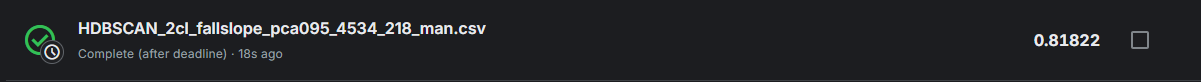